This involves a take-home task on a toy dataset for you to demonstrate your capability to work on the research project. Please read the instructions below carefully. The task itself is straightforward and should not take more than 2 days to finish. That said, you will have 14 days to finish the task (until 7/16).
1. Your task is to predict the "stance" label of the 5751 tweets in the attached csv file. Specifically, your goal is to infer the stance of a tweet with respect to COVID-19 vaccination. The stance belongs to one of the three categories, "in-favor", "against", "neutral-or-unclear".
2. Data description
    - columns:
        -   "tweet": the text
        -   "label_true": the ground-truth label annotated by human raters.
        -   "label_pred": your predictions. Please fill your predictions into this column.
3. In order to generate the predictions, please use the following model.
    - https://huggingface.co/google/flan-t5-large
4. To feed the tweet into the model, you have to install the HuggingFace and PyTorch package in Python.
    - The instruction to feed the tweets to the model is described here. You should be able to run it on a CPU machine without a GPU.
        - https://huggingface.co/google/flan-t5-large#running-the-model-on-a-cpu
5. Critically, when you feed the tweet into the model, you should embed the tweet in a prompt such that the model can generate the prediction for the stance. One simple prompt you can use is as follows.
> What is the stance of the following tweet with respect to COVID-19 vaccine?  Here is the tweet. "{THE  }"  Please use exactly one word from the following 3 categories to label it: "in-favor", "against", "neutral-or-unclear".
6. Now, please predict the label "label_pred" in the csv file "Q2_20230202_majority.csv". Please keep in mind that the actual dataset consists of around 1 million of tweets, so you want to solve the program programitically.
7. Meanwhile, please push your code to your GitHub in a private repository (don't set it to public!).
8. Fine-tuning is highly encouraged. You may need GPU for fine-tuning. Consider using https://colab.research.google.com/ if you don't have other GPU compute. T4 GPU it provides for free should be enought to fine-tune a FLAN-T5-Large model.
9. After you finished the task, please (a) invite me as a collaborator to the repository. (b) share with me the link to your github repo and (c) send me the csv file with the columns "label_pred" filled with your predictions.
Your attempt will be evaluated based on the three criteria.
(1) The model F1 score on the held-out test set that you did not see.
(2) The readability of the codes, including comments, the use of OOP, etc. Please also include a README file at the repo's root directory.
(3) Whether you use Git control properly. This includes clear git commits etc.

In [1]:
# Install the 'bitsandbytes' and 'accelerate' libraries for efficient model loading and optimization.
!pip install -q bitsandbytes accelerate

# Upgrade 'bitsandbytes' to the latest version to ensure compatibility and performance improvements.
!pip install -U bitsandbytes

# Install the latest version of Hugging Face's 'transformers' library directly from the main GitHub branch.
!pip install -q git+https://github.com/huggingface/transformers.git@main

# Install the latest version of Hugging Face's 'peft' (Parameter-Efficient Fine-Tuning) library from the main branch.
!pip install -q git+https://github.com/huggingface/peft.git@main


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
from google.colab import files  # For uploading files in Google Colab
import os  # For file and directory operations

# Define the filename for the dataset
filename = "Q2_20230202_majority 1.csv"

# Check if the file exists in the current working directory
if not os.path.exists(filename):
    # If file is not found, prompt the user to upload it
    print(f"'{filename}' not found. Please upload the file.")
    uploaded = files.upload()  # Opens a file upload dialog in Colab

# Set pandas option to display full column content without truncation
pd.set_option('display.max_colwidth', None)

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(filename)

# Display 5 random rows from the DataFrame to inspect the data
df.sample(5)


,tweet_id,created_at,tweet,label_majority,month
3650,1.384830e+18,2021-04-21 11:23:29+00:00,another pfizer blood clot victim in brisbane..,against,21-Apr
859,1.437975e+18,2021-09-15 03:02:08+00:00,"heartbreaking—5 kids are now orphaned after both mom+dad (age 37/39) dies of #covid19 weeks apart. the baby was born by c-section while mom was on a ventilator, doesn’t even have a name yet.😢 grandparents haven’t told the kids parents died yet. #vaccinate",in-favor,21-Sep
891,1.438913e+18,2021-09-17 17:09:27+00:00,"as an employer, i took the position that instituting mandatory vaccinations, changing conditions of employment, was against the law. it is a righteous position. it’s the right thing to do to not use that coercive tactic in my employees. i also can not break the law by asking my",against,21-Sep
1297,1.448793e+18,2021-10-14 23:30:05+00:00,i filed suit against saisd’s unlawful vaccine mandate and won! we are just getting started. #vaccinemandates,against,21-Oct
1918,1.467251e+18,2021-12-04 21:56:22+00:00,i was pretty tired today during training. i normally take the weekends off but with vacation coming up i figured i’d push through. i’m sluggish and got my booster shot and it’s starting to settle in 😪,in-favor,21-Dec


In [3]:
# Define a function to format the prompt for stance classification
def format_prompt(tweet):
    # Provide a few example tweet-stance pairs as context for the model
    examples = (
        f'Here are a few examples:'
        f'Tweet: "Vaccines saved my life" Stance: "in-favor"\n'
        f'Tweet: "Still deciding on those shots..." Stance: "neutral-or-unclear"\n'
        f'Tweet: "This vaccine is poison." Stance: "against"\n'
        f'Now analyze:\n'
    )

    # Create the full prompt by combining the instruction, examples, and the input tweet
    prompt = (
        f'What is the stance of the **author** of the following tweet toward COVID-19 vaccines?\n'
        f'Classify the stance as exactly one of: in-favor, against, neutral-or-unclear. '
        f'If the stance is unclear or mixed or if the tweet is off-topic, choose "neutral-or-unclear".\n'
        f'{examples}'
        f'Tweet: "{tweet}"\n'
        f'Respond with one exactly of the following options: "in-favor", "against", "neutral-or-unclear".'
    )

    return prompt

# Apply the format_prompt function to the 'tweet' column to create the 'prompt' column
df['prompt'] = df['tweet'].apply(format_prompt)

# Strip whitespace from labels and store in 'target' column for evaluation
df['target'] = df['label_majority'].str.strip()

print("prompt loaded")


prompt loaded


In [4]:
# Phase 1: Select rows where the stance is either 'in-favor' or 'against'
df_phase1 = df[df['target'].isin(['in-favor', 'against'])]

# Phase 2: Select rows where the stance is 'neutral-or-unclear'
df_phase2 = df[df['target'] == 'neutral-or-unclear']

# Phase 3: Create a balanced sample with 1000 rows from each category:
# 'in-favor', 'against', and 'neutral-or-unclear'
df_phase3 = pd.concat([
    df[df['target'] == 'in-favor'].sample(n=1000, random_state=1),    # Sample 1000 'in-favor' tweets
    df[df['target'] == 'against'].sample(n=1000, random_state=1),     # Sample 1000 'against' tweets
    df[df['target'] == 'neutral-or-unclear'].sample(n=1000, random_state=1),  # Sample 1000 'neutral' tweets
])

print("Phases are prepared.")

Phases are prepared.


In [5]:
from transformers import AutoTokenizer

# Load the tokenizer associated with the FLAN-T5 large model.
# (T5-style models use a text-to-text format; both inputs and targets are tokenized.)
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-large")

def tokenize(example):
    """
    Tokenize a single example dict with keys:
      - 'prompt': the full instruction + tweet text to classify
      - 'target': the gold label string (e.g., 'in-favor', 'against', 'neutral-or-unclear')

    Returns a dict of input features expected by HF Trainer/Datacollators:
      - input_ids, attention_mask (padded/truncated to max_length=256)
      - labels: token IDs for the target text (padded/truncated to length 8)
    """
    # Tokenize the prompt (model input). Truncate to 256 tokens; pad to that length.
    inputs = tokenizer(
        example['prompt'],
        max_length=256,
        truncation=True,
        padding="max_length",
    )

    # Tokenize the target label text. Short max_length since labels are tiny strings.
    labels = tokenizer(
        example['target'],
        max_length=8,
        truncation=True,
        padding="max_length",
    )

    # Add tokenized label IDs under 'labels' so HF Trainer can compute loss.
    inputs['labels'] = labels.input_ids
    return inputs

print("Tokenizer loaded.")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer loaded.


In [6]:
from transformers import AutoModelForSeq2SeqLM
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

# Load the FLAN-T5 large seq2seq model in 8-bit precision (bitsandbytes) to save GPU memory.
# Note: You may also want device_map="auto" (if using accelerate) for multi-GPU or CPU/GPU offloading.
model = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-large",
    load_in_8bit=True,
    # device_map="auto",  # <- uncomment if you want automatic placement
)

# Apply PEFT utility tweaks that make low-bit (k-bit) fine-tuning stable:
# - Cast some layer norms to FP32
# - Enable gradient checkpointing / input requires_grad as needed
model = prepare_model_for_kbit_training(model)

# Configure LoRA (Low-Rank Adapters) for parameter-efficient fine-tuning.
lora_config = LoraConfig(
    task_type="SEQ_2_SEQ_LM",  # Model/task family (important for PEFT internals)
    r=8,                       # Rank of the LoRA update matrices (trade-off: capacity vs. params)
    lora_alpha=16,             # Scaling factor; effective learning rate multiplier
    lora_dropout=0.1,          # Dropout on LoRA adapters during training
    target_modules=["q", "v"]  # Module name filters: which submodules to wrap with LoRA
                              # NOTE: For T5 models, you may need names like "q", "k", "v", "o",
                              # or more specific patterns (e.g., "SelfAttention.q" depending on HF version).
)

# Inject LoRA adapters into the base model; only adapter weights will be trained (PEFT).
model = get_peft_model(model, lora_config)


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [7]:
import shutil
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq, EarlyStoppingCallback
from datasets import Dataset

def train_phase(df_phase, phase_name, num_epochs, lr):
    """
    Fine-tunes the FLAN-T5 model on a specific phase dataset.

    Args:
        df_phase (pd.DataFrame): The phase-specific DataFrame with 'prompt' and 'target' columns.
        phase_name (str): Name of the training phase (used for saving outputs/logs).
        num_epochs (int): Number of epochs to train.
        lr (float): Learning rate for this phase.

    Steps:
        1. Convert pandas DataFrame to Hugging Face Dataset.
        2. Tokenize dataset using the custom tokenize() function.
        3. Split dataset into train (80%) and validation (20%).
        4. Configure Seq2SeqTrainingArguments.
        5. Initialize Seq2SeqTrainer with early stopping.
        6. Train the model, save the best checkpoint, and download it.
    """

    print(f"\n📘 Starting Phase: {phase_name} for {num_epochs} epoch(s) — LR: {lr}")

    # Convert pandas DataFrame to Hugging Face Dataset (only 'prompt' and 'target' columns)
    dataset = Dataset.from_pandas(df_phase[['prompt', 'target']])

    # Tokenize the dataset (batched for speed)
    tokenized = dataset.map(tokenize, batched=True)

    # Split into training (80%) and evaluation (20%) sets
    split = tokenized.train_test_split(test_size=0.2)
    train_dataset = split['train']
    eval_dataset = split['test']

    # Define training arguments
    training_args = Seq2SeqTrainingArguments(
        output_dir=f"./results_{phase_name}",  # Directory to save model checkpoints
        learning_rate=lr,
        per_device_train_batch_size=4,         # Adjust for GPU memory
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=2,         # Simulate larger batch size
        num_train_epochs=num_epochs,
        logging_strategy="epoch",              # Log metrics every epoch
        eval_strategy="epoch",                 # Evaluate every epoch
        save_strategy="epoch",                 # Save checkpoint every epoch
        logging_dir=f'./logs_{phase_name}',    # Log directory
        fp16=False,                            # Enable if mixed precision is supported
        load_best_model_at_end=True,           # Restore best checkpoint after training
        metric_for_best_model="eval_loss",     # Use validation loss for model selection
        greater_is_better=False,               # Lower loss = better
        save_total_limit=2,                    # Keep only last 2 checkpoints
        report_to="none"                       # Disable W&B/Hub reporting
    )

    # Data collator handles dynamic padding and formatting for seq2seq
    data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

    # Initialize Seq2SeqTrainer
    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        tokenizer=tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  # Stop if no improvement for 2 evals
    )

    # Train the model
    trainer.train()
    print(f"✅ Phase {phase_name} training complete!")

    # Save model and tokenizer
    model_path = f"./finetuned-flan-t5-vaccine_{phase_name}"
    model.save_pretrained(model_path)
    tokenizer.save_pretrained(model_path)

    # Compress and download the trained model
    shutil.make_archive(model_path, 'zip', model_path)
    files.download(f"{model_path}.zip")

print("Training function ready.")

Training function 


##Training Phases

In [9]:
train_phase(df_phase1, "phase1_easy", 2, lr=2e-5)


📘 Starting Phase: phase1_easy for 1 epoch(s) — LR: 2e-05


Map:   0%|          | 0/4711 [00:00<?, ? examples/s]

/tmp/ipython-input-7-4014438074.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
No label_names provided for model class `PeftModelForSeq2SeqLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autogra

Epoch,Training Loss,Validation Loss
1,15.487200,11.660830


✅ Phase phase1_easy training complete!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
train_phase(df_phase2, "phase2_neutral", 2, lr=1e-5)


📘 Starting Phase: phase2_neutral for 2 epoch(s) — LR: 1e-05


Map:   0%|          | 0/1040 [00:00<?, ? examples/s]

/tmp/ipython-input-7-4014438074.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
No label_names provided for model class `PeftModelForSeq2SeqLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autogra

Epoch,Training Loss,Validation Loss
1,0.178000,0.108069
2,0.094700,0.070240


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:185: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


✅ Phase phase2_neutral training complete!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# import zipfile
# import os

# model_dir = "finetuned-flan-t5-vaccine_phase2_neutral"
# zip_path = "/content/finetuned-flan-t5-vaccine_phase2_neutral.zip"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(model_dir)

In [11]:
# from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
# from peft import PeftModel, PeftConfig

# # Load tokenizer
# tokenizer = AutoTokenizer.from_pretrained(model_dir)

# # Load base model config from the PEFT adapter
# peft_config = PeftConfig.from_pretrained(model_dir)
# base_model = AutoModelForSeq2SeqLM.from_pretrained(peft_config.base_model_name_or_path, load_in_8bit=True)

# # Prepare model for training with bitsandbytes
# from peft import prepare_model_for_kbit_training
# base_model = prepare_model_for_kbit_training(base_model)

# # Load PEFT (LoRA) adapter on top of the base model
# model = PeftModel.from_pretrained(base_model, model_dir)


In [12]:
train_phase(df_phase3, "phase3_mixed", 5, lr=2e-5)


📘 Starting Phase: phase3_mixed for 5 epoch(s) — LR: 2e-05


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

/tmp/ipython-input-7-4014438074.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
No label_names provided for model class `PeftModelForSeq2SeqLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autogra

Epoch,Training Loss,Validation Loss
1,5.636900,2.086684
2,1.849600,1.439169
3,1.483200,0.792759
4,1.132100,0.309041
5,0.957300,0.264586


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:185: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reen

✅ Phase phase3_mixed training complete!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
train_phase(df_phase3, "phase3_mixed", 1, lr=2e-5)


📘 Starting Phase: phase3_mixed for 1 epoch(s) — LR: 2e-05


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

/tmp/ipython-input-7-4014438074.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
No label_names provided for model class `PeftModelForSeq2SeqLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autogra

Epoch,Training Loss,Validation Loss
1,0.688400,0.168516


✅ Phase phase3_mixed training complete!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
train_phase(df_phase3, "phase3_mixed", 3, lr=2e-5)


📘 Starting Phase: phase3_mixed for 3 epoch(s) — LR: 2e-05


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

/tmp/ipython-input-7-4014438074.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
No label_names provided for model class `PeftModelForSeq2SeqLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autogra

Epoch,Training Loss,Validation Loss
1,0.434900,0.121199
2,0.315500,0.118033
3,0.296200,0.118088


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:185: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reen

✅ Phase phase3_mixed training complete!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
train_phase(df_phase3, "phase3_mixed", 3, lr=2e-5)


📘 Starting Phase: phase3_mixed for 3 epoch(s) — LR: 2e-05


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

/tmp/ipython-input-7-4014438074.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
No label_names provided for model class `PeftModelForSeq2SeqLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autogra

Epoch,Training Loss,Validation Loss
1,0.241200,0.111893
2,0.212200,0.112683
3,0.215900,0.113080


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:185: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reen

✅ Phase phase3_mixed training complete!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
train_phase(df_phase3, "phase3_mixed", 1, lr=1e-6)


📘 Starting Phase: phase3_mixed for 1 epoch(s) — LR: 1e-06


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

/tmp/ipython-input-7-4014438074.py:39: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
No label_names provided for model class `PeftModelForSeq2SeqLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autogra

Epoch,Training Loss,Validation Loss
1,0.201900,0.112250


✅ Phase phase3_mixed training complete!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm

# Function to format a single tweet into the standardized prompt structure for stance classification
def format_prompt(tweet):
    # Provide few-shot examples for context (help the model understand the task)
    examples = (
        'Here are a few examples:\n'
        'Tweet: "Vaccines saved my life" Stance: "in-favor"\n'
        'Tweet: "Still deciding on those shots..." Stance: "neutral-or-unclear"\n'
        'Tweet: "This vaccine is poison." Stance: "Against"\n'
        'Now analyze:\n'
    )

    # Build the full prompt including instructions, examples, and the tweet to classify
    prompt = (
        f'What is the stance of the **author** of the following tweet toward COVID-19 vaccines?\n'
        f'Classify the stance as exactly one of: in-favor, against, neutral-or-unclear. '
        f'If the stance is unclear or mixed or if the tweet is off-topic, choose "neutral-or-unclear".\n'
        f'{examples}'
        f'Tweet: "{tweet}"\n'
        f'Respond with one exactly of the following options: "in-favor", "against", "neutral-or-unclear".'
    )
    return prompt

# Function for batch prediction of stances given a list of tweets
def predict_stances_batch(tweets, tokenizer, model):
    """
    Generate stance predictions for a batch of tweets using the fine-tuned FLAN-T5 model.

    Args:
        tweets (list of str): List of raw tweet texts to classify.
        tokenizer: Hugging Face tokenizer for FLAN-T5.
        model: Fine-tuned Hugging Face FLAN-T5 model.

    Returns:
        list of str: Predicted stance labels (e.g., 'in-favor', 'against', 'neutral-or-unclear').
    """
    # Convert tweets to formatted prompts
    prompts = [format_prompt(tweet) for tweet in tweets]

    # Tokenize prompts and move tensors to the model's device (GPU or CPU)
    inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)

    # Generate predictions without computing gradients (inference mode)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=10)  # Limit response length to avoid extra text

    # Decode the model outputs into readable strings, stripping special tokens and whitespace
    predictions = [tokenizer.decode(output, skip_special_tokens=True).strip() for output in outputs]

    return predictions

In [20]:
BATCH_SIZE = 32  # Number of tweets to run through the model at once

from math import ceil

preds = []   # Model predictions (strings)
labels = []  # Gold labels from the dataset
wrong = []   # Records of misclassified examples for later inspection/debugging

print("Generating predictions in batches...")

# Compute how many batches are needed to cover the whole DataFrame
num_batches = ceil(len(df) / BATCH_SIZE)

for i in tqdm(range(num_batches)):
    # Slice out the current batch
    batch_df = df.iloc[i * BATCH_SIZE : (i + 1) * BATCH_SIZE]

    # Extract raw tweet text and gold labels
    batch_tweets = batch_df['tweet'].tolist()
    batch_labels = batch_df['label_majority'].tolist()  # NOTE: raw label column; may include whitespace/casing

    # Run inference
    batch_preds = predict_stances_batch(batch_tweets, tokenizer, model)

    # Accumulate results
    preds.extend(batch_preds)
    labels.extend(batch_labels)

    # Track misclassifications
    for tweet, pred, label in zip(batch_tweets, batch_preds, batch_labels):
        if pred != label:
            wrong.append({
                "tweet": tweet,
                "label_majority": label,
                "prev_pred": pred  # You might rename this to 'predicted' or 'model_pred' for clarity
            })

# Attach predictions back to the original DataFrame (assumes df order unchanged since loop start)
df['predicted'] = preds

Generating predictions in batches...


  0%|          | 0/180 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:185: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
100%|██████████| 180/180 [09:00<00:00,  3.01s/it]


In [21]:
import pandas as pd

# Save entire DataFrame
df.to_csv("predictions.csv", index=False)

# Save incorrect predictions
wrong_df = pd.DataFrame(wrong)
wrong_df.to_csv("wrong_predictions.csv", index=False)

print("Saved predictions to predictions.csv")
print("Saved wrong predictions to wrong_predictions.csv")


Saved predictions to predictions.csv
Saved wrong predictions to wrong_predictions.csv


In [22]:
# Overall Accuracy
correct = sum(p == l for p, l in zip(preds, labels))
accuracies = [["Total Validation", f"{correct / len(labels):.3f}"]]

# Per-label Accuracy
label_list = ["in-favor", "against", "neutral-or-unclear"]
for label in label_list:
    total_label = labels.count(label)
    if total_label > 0:
        correct_label = sum(p == l for p, l in zip(preds, labels) if l == label)
        accuracy = correct_label / total_label
        accuracies.append([label, f"{accuracy:.3f}"])
    else:
        accuracies.append([label, "N/A"])

acc_df = pd.DataFrame(accuracies, columns=["Label", "Accuracy"])
print(acc_df)

                Label Accuracy
0    Total Validation    0.605
1            in-favor    0.621
2             against    0.777
3  neutral-or-unclear    0.264


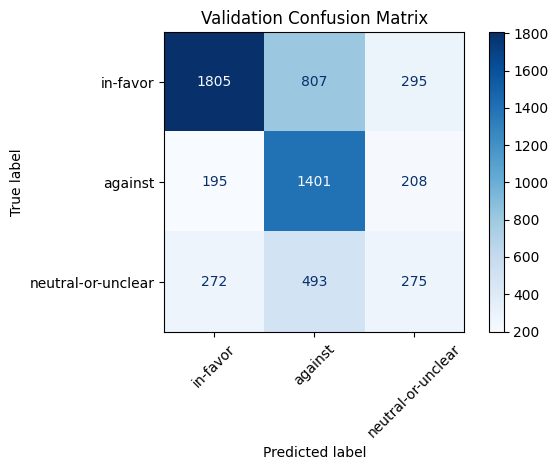

In [24]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds, labels=label_list)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_list)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()